In [18]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier

# Part 1

### Question 1

In [19]:
training_data = pd.read_csv("income.train.5k.csv")
dev_data = pd.read_csv("income.dev.csv")
val_train = len(training_data[training_data["target"] == ">50K"]) / len(training_data)
val_dev = len(dev_data[dev_data["target"] == ">50K"]) / len(dev_data)

print(f"The percentage of the training data that has a positive label (>50K) is: {val_train:.2%}")
print(f"The percentage of the dev data that has a positive label (>50K) is: {val_dev:.2%}")

The percentage of the training data that has a positive label (>50K) is: 25.02%
The percentage of the dev data that has a positive label (>50K) is: 23.60%


Based on my knowledge of the CURRENT average US per capital income (which is about 60k), I think it does not make sense, as they seem to be too low. The reason may be that these are historical data from a while ago.

### Question 2

In [20]:
print(f"The youngest age in the training data is: {min(training_data["age"])}" )
print(f"The oldest age in the training data is: {max(training_data["age"])}" )
print(f"The least amounts of hours per week do people in the training set work is: {min(training_data["hours"])}" )
print(f"The most amounts of hours per week do people in the training set work is: {max(training_data["hours"])}" )


The youngest age in the training data is: 17
The oldest age in the training data is: 90
The least amounts of hours per week do people in the training set work is: 1
The most amounts of hours per week do people in the training set work is: 99


### Question 3

##### Q: Why do we need to binarize all categorical fields?

Considering that categorical data represents different categories, it makes no sense not to binarize them, as it leads to misleading interpretation of the data itself during modeling. When working with numerical fields, their relative order and magnitude (say 1 is greater than 0) are meaningful, and will be used and interpreted during the modeling process. On the other hand, the numerical values of categorical fields should be treated as labels (0 and 1 simply represent two different categories,like coffee or tea). This means their relative order and magnitude should not be considered meaningful, and should have no impact on the models. If categorical data were fasely treated as numerical fields, the resulting models and outcomes will be uninterpretable.




##### Q: Why we do not want to binarize the two numerical fields, age and hours?

As mentioned earlier, when dealing with numerical fields, we consider their relative order and magnitude (say 2 is greater than 1, 1 is greater than 0). By binarizing them, there will be loss of information (regarding their ordinality and magnitude), as they will be treated as simply different categories. This may lead to less accurate model outcomes. 
However, there could be exception, when we do want to binarize numerical fields. Say if we want to compare the income of 17-year-old people with the rest of the people in the data, we may treat "age" as a categorical field and binarize it into two groups: one group with only 17-year-old people, and the other group that contains the rest of the people.


### Question 4

Yes, we should normalize them.
Normalizing numerical fields does not lead to loss of information in the data, the only consideration is whether that will give better or worse predictions/outcomes. Considering that the max distance on age is 90-17 = 73, the max distance on typical categorical fields will be much lower, mostly 1 (between 0 and 1, such as male or female in gender). During modeling, the fields with larger than max distance tend to have a higher weight, and therefore become more influential, or even dominant, in the model. In this case, not all fields are treated equally, and that leads to inaccurate results.


### Question 5

For categorical fields, we have 7 + 16 + 7 + 14 + 5 + 2 + 39 = 90 dimensions. For numerical fields, we have 2 dimensions (age and hours). So the total number of features (dimensions) is 90 + 2 = 92.



# Part 2

### Question 1

In [21]:
data = pd.read_csv("toy.csv")
print(data)

   id  age       sector
0   0   45  Federal-gov
1   1   33      Private
2   2   19      Private
3   3   47      Private
4   4   30    Local-gov
5   5   37      Private
6   6   35      Private
7   7   33      Private
8   8   40      Private
9   9   54  Federal-gov


In [22]:
data_age1 = data[['age']]
print(data_age1)

   age
0   45
1   33
2   19
3   47
4   30
5   37
6   35
7   33
8   40
9   54


In [23]:
data_age2 = data['age']
print(data_age2)

0    45
1    33
2    19
3    47
4    30
5    37
6    35
7    33
8    40
9    54
Name: age, dtype: int64


In [24]:
filtered_data = data[(data['age'] == 33) & (data['sector'] == 'Private')]
print(filtered_data)

   id  age   sector
1   1   33  Private
7   7   33  Private


### Question 2

In [25]:
encoded_data = pd.get_dummies(data, columns=["age", "sector"])
print(encoded_data.astype(int))

   id  age_19  age_30  age_33  age_35  age_37  age_40  age_45  age_47  age_54  \
0   0       0       0       0       0       0       0       1       0       0   
1   1       0       0       1       0       0       0       0       0       0   
2   2       1       0       0       0       0       0       0       0       0   
3   3       0       0       0       0       0       0       0       1       0   
4   4       0       1       0       0       0       0       0       0       0   
5   5       0       0       0       0       1       0       0       0       0   
6   6       0       0       0       1       0       0       0       0       0   
7   7       0       0       1       0       0       0       0       0       0   
8   8       0       0       0       0       0       1       0       0       0   
9   9       0       0       0       0       0       0       0       0       1   

   sector_Federal-gov  sector_Local-gov  sector_Private  
0                   1                 0           

It is impossible to be used in machine learning because problems may occur when some new features or new data in the testing set do not appear in the training set. Due to such feature dimension mismatch, the model trained on the training set becomes incompatible for the testing set, and it will no longer work.


### Question 3

In [26]:
data2 = data[['age','sector']]
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(data2)
binary_data = encoder.transform(data2)
print(binary_data)

[[0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0.]]


In [27]:
training_data = pd.read_csv("income.train.5k.csv")
predictor_columns = ['age', 'sector', 'edu', 'marriage', 'occupation', 'race', 'sex', 'hours', 'country']
training_data_2 = training_data[predictor_columns]
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(training_data_2)
binary_training_data = encoder.transform(training_data_2)
feature_names = encoder.get_feature_names_out()
print(f"Feature dimension after binarization is: {len(feature_names)}")

Feature dimension after binarization is: 230


It shows the feature dimension is 230, which does not match the answer from Part 1 Q5. The answers are different because here we also binarized the two numerical fields, and that adds additional feature dimension.


### Question 4

##### (a)

In [28]:
binary_training_data = encoder.transform(training_data_2)
target_training = (training_data['target'] == '>50K').astype(int)

# Processing dev set
dev_data = pd.read_csv("income.dev.csv")
dev_data_2 = dev_data[predictor_columns]
binary_dev_data = encoder.transform(dev_data_2) 
target_dev = (dev_data['target'] == '>50K').astype(int)

#Fit and evaluate k-NN on both data sets
error_rates_training = []
error_rates_dev_1 = []
positive_rates_training = []
positive_rates_dev = []
k_values = list(range(1, 101, 2)) # range of k, odd num from 1 to 100

for k in k_values:
    # fit k-NN model
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(binary_training_data, target_training)

    # predictions
    predict_training = knn.predict(binary_training_data)    # apply on training set
    predict_dev = knn.predict(binary_dev_data)  # apply on dev set

    # Calculate error rate
    error_rates_training_curr = np.mean(predict_training != target_training)
    error_rates_dev_curr = np.mean(predict_dev != target_dev)

    error_rates_training.append(error_rates_training_curr)
    error_rates_dev_1.append(error_rates_dev_curr)

    # Calculat predicted positive rates
    positive_rates_training_curr = np.mean(predict_training == 1)
    positive_rates_dev_curr = np.mean(predict_dev == 1)
    
    positive_rates_training.append(positive_rates_training_curr)
    positive_rates_dev.append(positive_rates_dev_curr)

    # Print result
    print(f"k={k} train_err {error_rates_training_curr*100:.1f}% (+:{positive_rates_training_curr*100:.1f}%) "
          f"dev_err {error_rates_dev_curr*100:.1f}% (+:{positive_rates_dev_curr*100:.1f}%)")
 

k=1 train_err 1.5% (+:25.1%) dev_err 23.2% (+:24.8%)
k=3 train_err 11.8% (+:23.1%) dev_err 17.9% (+:21.5%)
k=5 train_err 14.5% (+:22.5%) dev_err 17.0% (+:20.4%)
k=7 train_err 15.4% (+:21.7%) dev_err 17.1% (+:20.1%)
k=9 train_err 16.5% (+:21.7%) dev_err 16.3% (+:20.3%)
k=11 train_err 17.1% (+:20.7%) dev_err 16.9% (+:18.9%)
k=13 train_err 17.0% (+:19.9%) dev_err 16.9% (+:17.9%)
k=15 train_err 17.0% (+:20.2%) dev_err 16.6% (+:18.4%)
k=17 train_err 17.3% (+:19.6%) dev_err 16.0% (+:18.4%)
k=19 train_err 17.4% (+:19.4%) dev_err 16.4% (+:18.2%)
k=21 train_err 17.2% (+:19.0%) dev_err 16.2% (+:18.0%)
k=23 train_err 17.4% (+:19.2%) dev_err 16.2% (+:18.4%)
k=25 train_err 17.4% (+:18.9%) dev_err 16.2% (+:17.2%)
k=27 train_err 17.3% (+:18.8%) dev_err 16.6% (+:17.8%)
k=29 train_err 17.7% (+:18.4%) dev_err 16.5% (+:17.5%)
k=31 train_err 17.7% (+:18.5%) dev_err 16.3% (+:17.9%)
k=33 train_err 17.4% (+:18.2%) dev_err 16.1% (+:17.5%)
k=35 train_err 17.5% (+:18.3%) dev_err 16.8% (+:17.2%)
k=37 train_err 1

The best error rate on dev set is 15.7%, at k = 37, 79 and 87 (they all give same dev set error rate).

##### (b)

The training error is not 0% when k = 1. When k was chosen to be 1, each data point is classified based on its single nearest neighbor. Our 1-NN model provides wrong predictions because some datapoints’ single nearest neighbors have different labels than the labels of that datapoint itself. In this dataset, the reason could be that people with the duplicate features have different income levels.


In [29]:
feature_columns = ['sector', 'edu', 'marriage', 'occupation', 'race', 'sex', 'country', 'age', 'hours']
duplicates = training_data[training_data.duplicated(subset=feature_columns, keep=False)]

grouped_duplicates = duplicates.groupby(feature_columns)     # group them by their features
conflicts = 0
for name, group in grouped_duplicates:
     if len(group['target'].unique()) > 1:  # check for different labels
        conflicts += 1
print(f"Total datapoints with same features but conflicting labels: {conflicts}")

Total datapoints with same features but conflicting labels: 69


After looking at the training set data, there are 69 data points with duplicate features but conflict target values (income levels). This confirms our previous answer.

##### (c)

The training error rate is the lowest when k = 1, then increases as k increases. The dev error rate is the highest when k = 1, it decreases for a short period when k increases, until reaching a minimum at k = 41. After that, it increases again, and later remains stable at around 15.3%.


There seems to be no change in the running speed, as training time for different values of k (from 1 to 99) are very similar.


##### (d)

When k = $\infty$, the prediction of a single data point relies on the labels of all the other data points in the training set. The model will end up giving predictions based on the majority of the dataset, so most of the predictions will be the same, ignoring their different features and patterns. Therefore, it is an underfitting problem, because it simply predicts the most common cases from the dataset. 


When k = 1, the prediction of a data point relies on the label of its closest neighbor, which means the predictions could be sensitive to outliers or small changes in the data. When most, or all of the outliers are captured by the model, it does not reflect the true pattern of the data. Therefore, it is an overfitting issue. Also in our model, it shows that training error rate is extremely low while dev error rate is extremely high, this is also a sign of an overfitting model.


##### (e)

My error rate on the public leaderboard is 0.17, and my ranking should be 24.

I don't have the screenshot of the ranking of this initial result I submitted, but I have the screenshot of the score and the ranking of my current best model attached below:

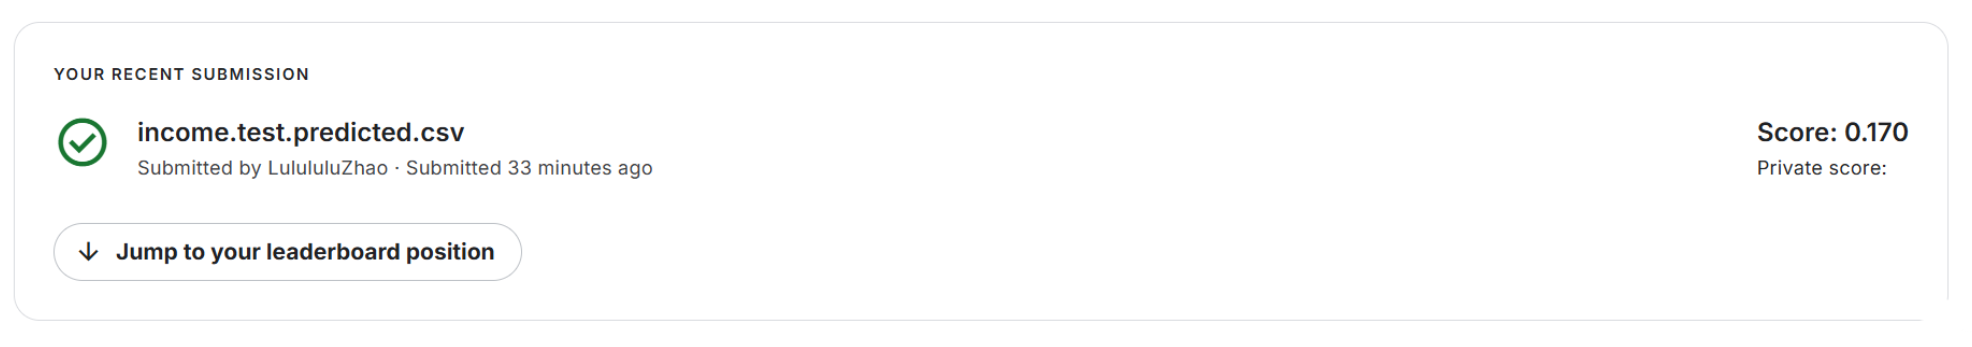

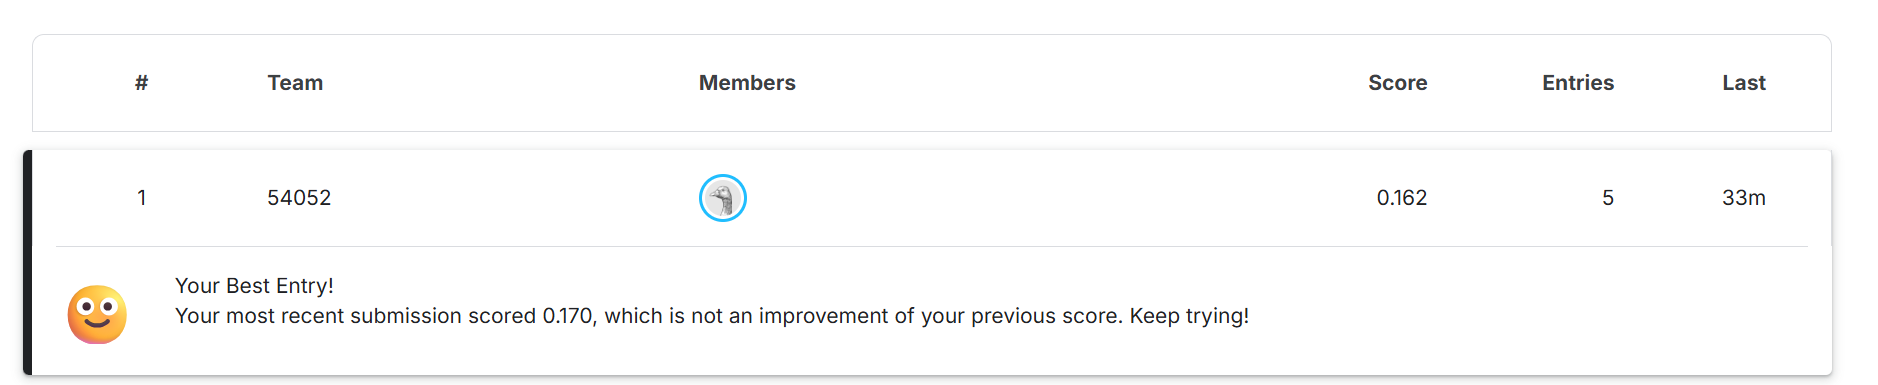

## Part 3

### Question 1

In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

num_processor = 'passthrough'
cat_processor = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Process training data and train the encoder
training_data_3 = training_data.drop('target', axis = 1)
categorical = ['sector', 'edu', 'marriage', 'occupation', 'race','sex', 'country']
numerical = ['age', 'hours']
preprocessor = ColumnTransformer([('num', num_processor, numerical),
                                  ('cat', cat_processor, categorical)])
preprocessor.fit(training_data_3)
processed_train_data = preprocessor.transform(training_data_3)
# print(len(preprocessor.get_feature_names_out()))

# Process dev data
dev_data_3 = dev_data.drop('target', axis = 1)
processed_dev_data = preprocessor.transform(dev_data_3)

#target_dev = (dev_data['target'] == '>50K').astype(int)

#Fit and evaluate k-NN on both data sets
error_rates_training = []
error_rates_dev_2 = []
positive_rates_training = []
positive_rates_dev = []
k_values = list(range(1, 101, 2)) # range of k, odd num from 1 to 100

for k in k_values:
    # fit k-NN model
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(processed_train_data, target_training)

    # predictions
    predict_training = knn.predict(processed_train_data)    # apply on training set
    predict_dev = knn.predict(processed_dev_data)  # apply on dev set

    # Calculate error rate
    error_rates_training_curr = np.mean(predict_training != target_training)
    error_rates_dev_curr = np.mean(predict_dev != target_dev)

    error_rates_training.append(error_rates_training_curr)
    error_rates_dev_2.append(error_rates_dev_curr)

    # Calculat predicted positive rates
    positive_rates_training_curr = np.mean(predict_training == 1)
    positive_rates_dev_curr = np.mean(predict_dev == 1)
    
    positive_rates_training.append(positive_rates_training_curr)
    positive_rates_dev.append(positive_rates_dev_curr)

    # Print result
    print(f"k={k} train_err {error_rates_training_curr*100:.1f}% (+:{positive_rates_training_curr*100:.1f}%) "
          f"dev_err {error_rates_dev_curr*100:.1f}% (+:{positive_rates_dev_curr*100:.1f}%)")

k=1 train_err 1.5% (+:25.1%) dev_err 26.9% (+:27.3%)
k=3 train_err 12.9% (+:24.9%) dev_err 24.3% (+:25.5%)
k=5 train_err 15.5% (+:23.1%) dev_err 23.6% (+:25.2%)
k=7 train_err 16.7% (+:22.9%) dev_err 23.3% (+:22.7%)
k=9 train_err 18.3% (+:22.1%) dev_err 22.2% (+:22.4%)
k=11 train_err 18.8% (+:21.8%) dev_err 21.8% (+:21.8%)
k=13 train_err 19.1% (+:21.8%) dev_err 22.2% (+:21.8%)
k=15 train_err 18.9% (+:21.4%) dev_err 21.9% (+:20.9%)
k=17 train_err 19.6% (+:21.6%) dev_err 22.0% (+:20.4%)
k=19 train_err 19.5% (+:21.0%) dev_err 21.8% (+:20.6%)
k=21 train_err 19.8% (+:20.1%) dev_err 22.1% (+:19.5%)
k=23 train_err 20.1% (+:19.8%) dev_err 21.7% (+:19.9%)
k=25 train_err 20.3% (+:19.7%) dev_err 22.3% (+:19.3%)
k=27 train_err 20.7% (+:19.5%) dev_err 22.3% (+:18.7%)
k=29 train_err 20.8% (+:18.7%) dev_err 21.9% (+:17.9%)
k=31 train_err 21.1% (+:18.2%) dev_err 21.9% (+:18.5%)
k=33 train_err 21.5% (+:17.9%) dev_err 21.5% (+:18.1%)
k=35 train_err 21.8% (+:17.7%) dev_err 21.2% (+:17.6%)
k=37 train_err 2

The result shows an 1-NN dev error at 26.9%, and the best dev error rate of 21.2% at k = 35. Although the correct approach has been used this time, I notice its performance is actually worse than the initial result (in Part 2 Q4a). One reason I can think of is the scaling of the numerical fields, their magnitude are much larger than our binarized fields (0/1). By applying binarization to the numerical fields, although it is an incorrect approach, it brings their values down in the same scale as the other categorical fields and avoid their dominant influence on our model. Therefore it gives better results.

### Question 2

In [31]:
from sklearn.preprocessing import MinMaxScaler

num_processor = MinMaxScaler(feature_range=(0, 2))
cat_processor = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Process training data and train the encoder
training_data_4 = training_data.drop('target', axis = 1)
categorical = ['sector', 'edu', 'marriage', 'occupation', 'race','sex', 'country']
numerical = ['age', 'hours']
preprocessor2 = ColumnTransformer([('num', num_processor, numerical),
                                  ('cat', cat_processor, categorical)])
preprocessor2.fit(training_data_4)
processed_train_data_2 = preprocessor2.transform(training_data_4)
# print(len(preprocessor_2.get_feature_names_out()))

# Process dev data
dev_data_4 = dev_data.drop('target', axis = 1)
processed_dev_data_2 = preprocessor2.transform(dev_data_4)


#Fit and evaluate k-NN on both data sets
error_rates_training = []
error_rates_dev_3 = []
positive_rates_training = []
positive_rates_dev = []
k_values = list(range(1, 101, 2)) # range of k, odd num from 1 to 100

for k in k_values:
    # fit k-NN model
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(processed_train_data_2, target_training)

    # predictions
    predict_training = knn.predict(processed_train_data_2)    # apply on training set
    predict_dev = knn.predict(processed_dev_data_2)  # apply on dev set

    # Calculate error rate
    error_rates_training_curr = np.mean(predict_training != target_training)
    error_rates_dev_curr = np.mean(predict_dev != target_dev)

    error_rates_training.append(error_rates_training_curr)
    error_rates_dev_3.append(error_rates_dev_curr)

    # Calculat predicted positive rates
    positive_rates_training_curr = np.mean(predict_training == 1)
    positive_rates_dev_curr = np.mean(predict_dev == 1)
    
    positive_rates_training.append(positive_rates_training_curr)
    positive_rates_dev.append(positive_rates_dev_curr)

    # Print result
    print(f"k={k} train_err {error_rates_training_curr*100:.1f}% (+:{positive_rates_training_curr*100:.1f}%) "
          f"dev_err {error_rates_dev_curr*100:.1f}% (+:{positive_rates_dev_curr*100:.1f}%)")

k=1 train_err 1.5% (+:25.1%) dev_err 23.9% (+:27.1%)
k=3 train_err 11.6% (+:24.0%) dev_err 19.1% (+:25.9%)
k=5 train_err 13.7% (+:24.1%) dev_err 17.8% (+:24.2%)
k=7 train_err 14.3% (+:24.0%) dev_err 16.9% (+:24.1%)
k=9 train_err 15.5% (+:23.6%) dev_err 16.1% (+:22.7%)
k=11 train_err 16.2% (+:23.6%) dev_err 16.4% (+:21.0%)
k=13 train_err 16.3% (+:23.5%) dev_err 16.3% (+:21.9%)
k=15 train_err 16.5% (+:23.2%) dev_err 15.8% (+:21.8%)
k=17 train_err 16.6% (+:22.9%) dev_err 15.7% (+:21.9%)
k=19 train_err 16.8% (+:22.4%) dev_err 16.2% (+:21.0%)
k=21 train_err 17.0% (+:22.2%) dev_err 15.8% (+:21.0%)
k=23 train_err 17.1% (+:22.3%) dev_err 15.5% (+:21.5%)
k=25 train_err 16.9% (+:22.3%) dev_err 15.1% (+:21.3%)
k=27 train_err 17.1% (+:22.1%) dev_err 15.6% (+:20.8%)
k=29 train_err 17.0% (+:22.0%) dev_err 15.2% (+:21.0%)
k=31 train_err 16.9% (+:21.9%) dev_err 15.2% (+:21.0%)
k=33 train_err 17.2% (+:21.7%) dev_err 15.6% (+:21.4%)
k=35 train_err 17.2% (+:21.5%) dev_err 15.2% (+:21.0%)
k=37 train_err 1

The result shows an 1-NN dev error at 23.9%, and the best dev error rate of 14.6% at k = 39 and 41. The reason is scaled numerical fields no longer dominate the distance calculation, and therefore provides better results overall.

### Question 3

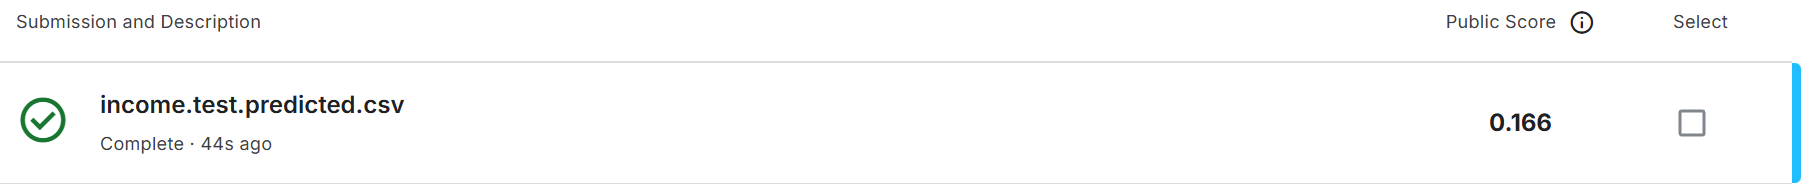

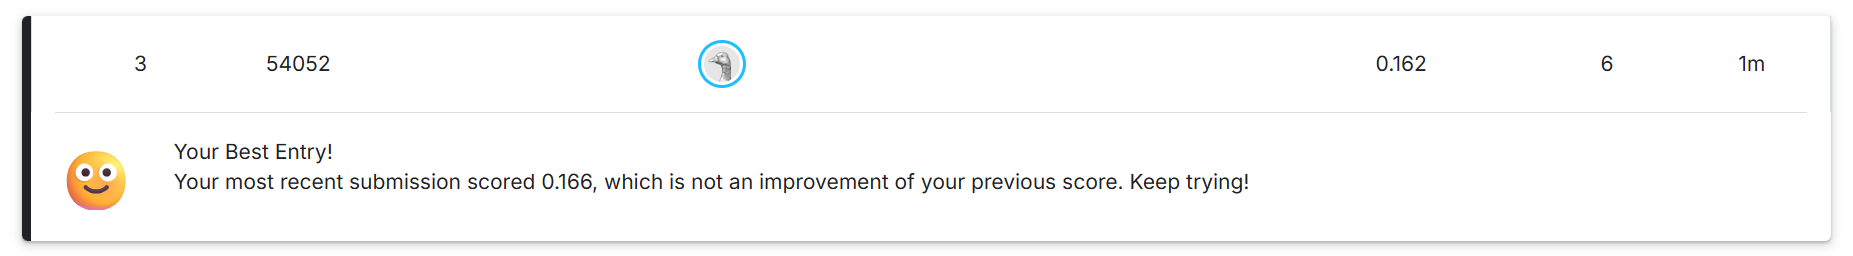

## Part 4

### Question 1

In [32]:

    
def calculate_distance(data1, array, metric):
    # find the euclidean or manhattan distance between two datpoint 
    if metric == 'euclidean':
        return(np.linalg.norm(data1 - array, axis=1))
    elif metric == 'manhattan':
        return(np.sum(np.abs(data1 - array), axis=1))
    else:
        print("Metric must be 'euclidean' or 'manhattan'")
        return None
        

def find_neighbors_knn(sample, X_train, k, metric):
    # find the kth nearlest neighbor based on given metric (euclidean/manhattan)
    sample_2d = sample.reshape(1, -1)
    distances = calculate_distance(sample_2d, X_train, metric)
    idx = np.argpartition(distances, k)[:k]
    return idx


def predict_knn(X_train, Y_train, X_test, k, metric):
    # making predictions based on knn
    predictions = []
    for i in range(len(X_test)):
        sample_x = X_test[i]
        idx = find_neighbors_knn(sample_x, X_train, k, metric)
        neighbor_labels = Y_train[idx]
        pred = int(neighbor_labels.mean() >= 0.5) 
        predictions.append(pred)
        
        # labels = Y_train.iloc[idx] if hasattr(Y_train, 'iloc') else Y_train[idx]
        # unique, counts = np.unique(labels, return_counts=True)
        # pred = unique[np.argmax(counts)]
        # predictions.append(pred)
    return np.array(predictions)



In [33]:
# continue with processed_train_data_2, target_training and processed_dev_data_2

dev_sample = processed_dev_data_2[0].reshape(1, -1)
knn = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn.fit(processed_train_data_2, target_training)
distances, indices = knn.kneighbors(dev_sample, n_neighbors=3)

print(f"Test data point: {dev_sample[0]}")
print(f"Based on the sklearn implementation, we have:")
print(f"Distances to the 3 closest neighbors: {distances[0]}")
print(f"Indices of the 3 closest neighbors: {indices[0]}")

indices2 = find_neighbors_knn(dev_sample, processed_train_data_2, 3, 'euclidean')

print(indices2)
distances2 = []
for i in indices2:
    dist = np.linalg.norm(dev_sample - processed_train_data_2[i], axis=1)
    distances2.append(dist)

print(f"Based on my own implementation, we have:")
print(f"Distances to the 3 closest neighbors: {np.concatenate(distances2)}")
print(f"Indices of the 3 closest neighbors: {indices2}")

Test data point: [0.76712329 0.89795918 1.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 1.         0.         0.         0.         0.         0.
 0.         0.         0.         1.         0.         0.
 0.         0.         1.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         1.         0.         1.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         1.
 0.         0.        ]
Based on the sklearn implementation, we have:
Distances to the 3 closest n

In [34]:
print(f"The sklearn implementation:")
for i in range(3):
    train_idx = indices[0][i]
    neighbor_features = processed_train_data_2[train_idx].reshape(1, -1)
    neighbor_label = target_training[train_idx]

    euclidean1 = np.linalg.norm(dev_sample[0] - neighbor_features, axis=1)
    manhattan1 = np.sum(np.abs(dev_sample[0] - neighbor_features), axis=1)
    print(f"Between the {i+1}th closest neighbor (with index {train_idx}) and the query person:")
    print(f" The Euclidean distances is {euclidean1.item():.4f}.")
    print(f" The Manhattan distances is {manhattan1.item():.4f}.")



print()
print(f"My own implementation:")
for i in range(3):
    train_idx = indices2[i]
    neighbor_features = processed_train_data_2[train_idx]
    neighbor_label = target_training[train_idx]

    euclidean2 = np.linalg.norm(dev_sample[0] - neighbor_features)
    manhattan2 = np.sum(np.abs(dev_sample[0] - neighbor_features))
    print(f"Between the {i+1}th closest neighbor (with index {train_idx}) and the query person:")
    print(f" The Euclidean distances is {euclidean2:.4f}.")
    print(f" The Manhattan distances is {manhattan2:.4f}.")


The sklearn implementation:
Between the 1th closest neighbor (with index 4872) and the query person:
 The Euclidean distances is 0.3344.
 The Manhattan distances is 0.3900.
Between the 2th closest neighbor (with index 4787) and the query person:
 The Euclidean distances is 1.4153.
 The Manhattan distances is 2.0548.
Between the 3th closest neighbor (with index 2591) and the query person:
 The Euclidean distances is 1.4167.
 The Manhattan distances is 2.1026.

My own implementation:
Between the 1th closest neighbor (with index 4787) and the query person:
 The Euclidean distances is 1.4153.
 The Manhattan distances is 2.0548.
Between the 2th closest neighbor (with index 4872) and the query person:
 The Euclidean distances is 0.3344.
 The Manhattan distances is 0.3900.
Between the 3th closest neighbor (with index 2591) and the query person:
 The Euclidean distances is 1.4167.
 The Manhattan distances is 2.1026.


As shown above, both the sklearn implementation and my own implementation give the same results. They give identical indices for the 3 nearest neighbors, with the same Euclidean and Manhattan distance for each of the neighbor. 



### Question 2

##### (a)

There is no work in training after the feature map, since knn only stores the training data, and computation only happends during testing process.

##### (b)

In order to test one example, we need to calculate its distance to each training sample, which is O(|D|) time. During each calculation, each feature will be used once, which is O(d) time. Therefore, the time complexity of k-NN to test one example would be O(d * |D|).


##### (c)

No, we do not need to sort the distance first then choose the top k. Instead, we can use $numpy.argpartition()$ to ensure the $k^{th}$ top elements were sorted in their correct position, without sorting the entire list.

##### (d)

I used $np.linalg.norm(..., axis=1)$ and $np.argpartition()$ to speed up the process. $np.linalg.norm(..., axis=1)$ computes the distance in vector/matrix form, while $np.argpartition()$ speed up the process of choosing the k nearest neighbor by partial sorting, instead of sorting the entire list.

##### (e)

In [35]:
# continue with processed_train_data_2, target_training and processed_dev_data_2

#Fit and evaluate k-NN on both data sets
error_rates_training = []
error_rates_dev_4 = []
positive_rates_training = []
positive_rates_dev = []
k_values = list(range(1, 101, 2)) # range of k, odd num from 1 to 100

for k in k_values:

    # predictions
    predict_training = predict_knn(processed_train_data_2, target_training,
                                   processed_train_data_2, k, metric = 'euclidean')
    
    predict_dev = predict_knn(processed_train_data_2, target_training,
                              processed_dev_data_2, k, metric = 'euclidean')

    # Calculate error rate
    error_rates_training_curr = np.mean(predict_training != target_training)
    error_rates_dev_curr = np.mean(predict_dev != target_dev)

    error_rates_training.append(error_rates_training_curr)
    error_rates_dev_4.append(error_rates_dev_curr)

    # Calculat predicted positive rates
    positive_rates_training_curr = np.mean(predict_training == 1)
    positive_rates_dev_curr = np.mean(predict_dev == 1)
    
    positive_rates_training.append(positive_rates_training_curr)
    positive_rates_dev.append(positive_rates_dev_curr)

    # Print result
    print(f"k={k} train_err {error_rates_training_curr*100:.1f}% (+:{positive_rates_training_curr*100:.1f}%) "
          f"dev_err {error_rates_dev_curr*100:.1f}% (+:{positive_rates_dev_curr*100:.1f}%)")


k=1 train_err 1.5% (+:25.1%) dev_err 23.9% (+:27.3%)
k=3 train_err 11.4% (+:23.9%) dev_err 19.6% (+:25.4%)
k=5 train_err 13.7% (+:23.6%) dev_err 17.8% (+:24.4%)
k=7 train_err 14.3% (+:23.8%) dev_err 16.6% (+:24.0%)
k=9 train_err 15.4% (+:23.6%) dev_err 15.3% (+:22.5%)
k=11 train_err 16.5% (+:23.6%) dev_err 16.4% (+:21.2%)
k=13 train_err 16.5% (+:23.5%) dev_err 16.7% (+:21.9%)
k=15 train_err 16.4% (+:23.1%) dev_err 15.9% (+:21.9%)
k=17 train_err 16.7% (+:22.8%) dev_err 15.8% (+:21.6%)
k=19 train_err 16.7% (+:22.5%) dev_err 16.4% (+:20.8%)
k=21 train_err 16.9% (+:22.2%) dev_err 16.2% (+:21.0%)
k=23 train_err 17.0% (+:22.3%) dev_err 15.5% (+:21.7%)
k=25 train_err 16.9% (+:22.4%) dev_err 15.6% (+:21.4%)
k=27 train_err 16.9% (+:22.2%) dev_err 15.6% (+:20.8%)
k=29 train_err 17.0% (+:21.8%) dev_err 15.1% (+:21.1%)
k=31 train_err 16.9% (+:21.9%) dev_err 15.2% (+:21.2%)
k=33 train_err 17.0% (+:21.6%) dev_err 15.6% (+:21.4%)
k=35 train_err 17.2% (+:21.4%) dev_err 15.3% (+:20.7%)
k=37 train_err 1

It takes 12.533s user time to print the training and dev errors for k = 99 on ENGR servers.

### Question 3

In [36]:
# import numpy as np
# import pandas as pd
# from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.compose import ColumnTransformer

#Fit and evaluate k-NN on both data sets
error_rates_training = []
error_rates_dev_5 = []
positive_rates_training = []
positive_rates_dev = []
k_values = list(range(1, 101, 2)) # range of k, odd num from 1 to 100

for k in k_values:

    # predictions
    predict_training = predict_knn(processed_train_data_2, target_training,
                                   processed_train_data_2, k, metric = 'manhattan')
    
    predict_dev = predict_knn(processed_train_data_2, target_training,
                              processed_dev_data_2, k, metric = 'manhattan')

    # Calculate error rate
    error_rates_training_curr = np.mean(predict_training != target_training)
    error_rates_dev_curr = np.mean(predict_dev != target_dev)

    error_rates_training.append(error_rates_training_curr)
    error_rates_dev_5.append(error_rates_dev_curr)

    # Calculat predicted positive rates
    positive_rates_training_curr = np.mean(predict_training == 1)
    positive_rates_dev_curr = np.mean(predict_dev == 1)
    
    positive_rates_training.append(positive_rates_training_curr)
    positive_rates_dev.append(positive_rates_dev_curr)

    # Print result
    print(f"k={k} train_err {error_rates_training_curr*100:.1f}% (+:{positive_rates_training_curr*100:.1f}%) "
          f"dev_err {error_rates_dev_curr*100:.1f}% (+:{positive_rates_dev_curr*100:.1f}%)")



k=1 train_err 1.5% (+:25.1%) dev_err 24.0% (+:27.2%)
k=3 train_err 11.6% (+:23.9%) dev_err 19.7% (+:26.1%)
k=5 train_err 14.0% (+:23.9%) dev_err 17.6% (+:25.0%)
k=7 train_err 14.5% (+:24.0%) dev_err 16.6% (+:24.0%)
k=9 train_err 15.5% (+:23.6%) dev_err 16.2% (+:22.2%)
k=11 train_err 16.2% (+:23.4%) dev_err 16.3% (+:21.9%)
k=13 train_err 16.5% (+:23.6%) dev_err 16.5% (+:22.3%)
k=15 train_err 16.8% (+:22.8%) dev_err 16.3% (+:21.7%)
k=17 train_err 16.9% (+:22.8%) dev_err 15.5% (+:21.1%)
k=19 train_err 17.0% (+:22.5%) dev_err 16.0% (+:21.0%)
k=21 train_err 17.0% (+:22.2%) dev_err 16.6% (+:21.2%)
k=23 train_err 17.1% (+:22.3%) dev_err 16.2% (+:21.6%)
k=25 train_err 17.0% (+:22.1%) dev_err 15.7% (+:21.1%)
k=27 train_err 16.9% (+:21.8%) dev_err 15.8% (+:20.6%)
k=29 train_err 16.8% (+:21.3%) dev_err 16.0% (+:20.6%)
k=31 train_err 17.0% (+:21.2%) dev_err 15.9% (+:20.5%)
k=33 train_err 17.0% (+:21.0%) dev_err 15.8% (+:20.2%)
k=35 train_err 16.9% (+:21.1%) dev_err 15.1% (+:20.5%)
k=37 train_err 1

Manhattan distance gives slightly better result. It gives the best dev error rate of 14.3% at k = 41.

## Part 5

### Question 1

My best result presents when Manhattan distance was used with k = 41.

### Question 2

My best dev error rate presents with my own implementation, which is 14.3% at k = 41 with a positive ratio of (+:20.4%).

### Question 3

its +20.9%

## Part 6

### Question 1

The major drawbacks of k-NN that I observed are: 
Large memory needed for data storage and computation,
Equal weight among different features,
Inefficient sequential computing,
Lack of automating selections over different choices of distance and k, and
Lack of noise handling in data


### Question 2

Yes, the best-performing models tend to exaggerate the existing bias in the training data, it is an overfitting issue. Due to the nature of k-NN, the predicted label of a specific data point depends on the nearby sample points. Therefore, existing bias in those nearby samples will be learned and amplified on the prediction on that single data point.
It is potentially a social issue because such bias could potentially lead to discrimination against certain gender, race or age group in real-world application, while making them appear objective.


## Part 6

Minimum error rates:
Naive: 0.1570 at k=37
Smart: 0.2120 at k=35
Smart+Scaling: 0.1460 at k=39


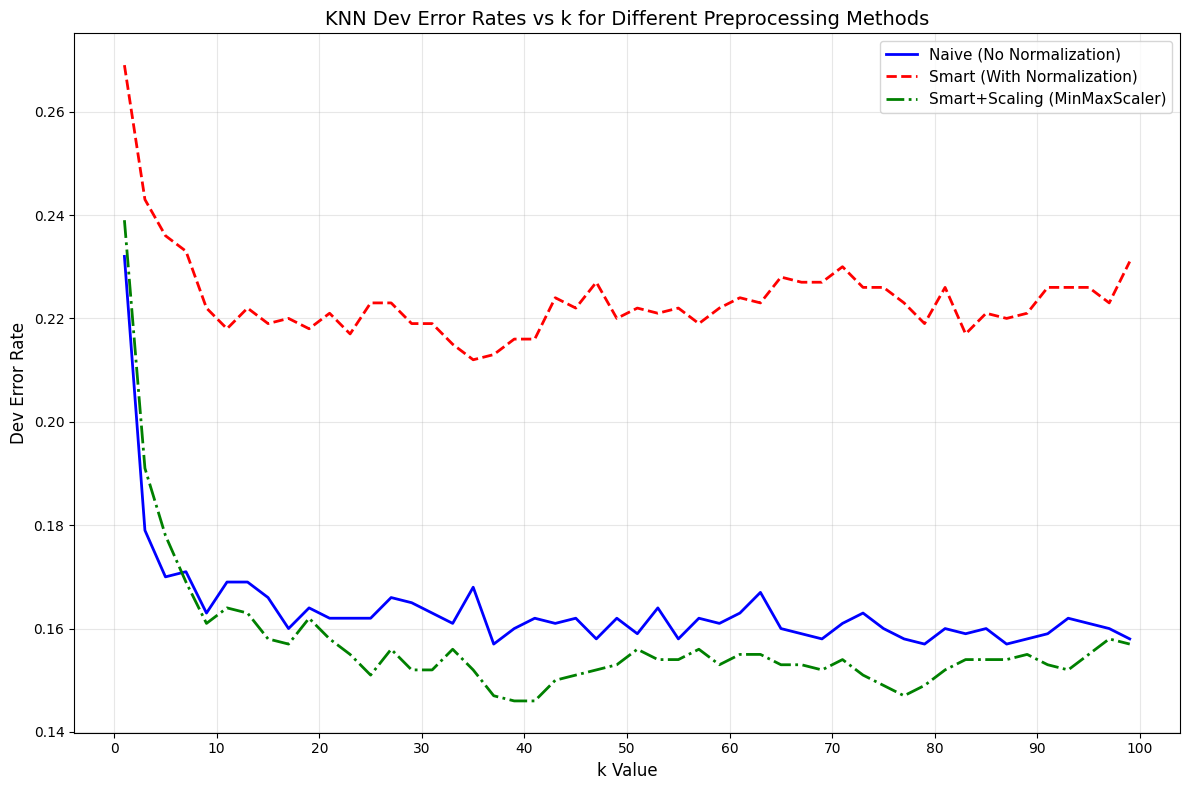

In [38]:
import matplotlib.pyplot as plt

# Extract dev error rates from each part
# error_rates_dev_1 = error_rates_dev  # from Part 1
# error_rates_dev_2 = error_rates_dev  # from Part 2
# error_rates_dev_3 = error_rates_dev  # from Part 3

# Part 4: Custom implementation (but you mentioned Euclidean for all three)
# We'll use Part 1, Part 3, and either Part 2 or Part 4 for the third version

# Create the plot
plt.figure(figsize=(12, 8))

# Plot all three error rate curves
plt.plot(k_values, error_rates_dev_1, 'b-', linewidth=2, label='Naive (No Normalization)')
plt.plot(k_values, error_rates_dev_2, 'r--', linewidth=2, label='Smart (With Normalization)')
plt.plot(k_values, error_rates_dev_3, 'g-.', linewidth=2, label='Smart+Scaling (MinMaxScaler)')

# Customize the plot
plt.xlabel('k Value', fontsize=12)
plt.ylabel('Dev Error Rate', fontsize=12)
plt.title('KNN Dev Error Rates vs k for Different Preprocessing Methods', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Set x-axis to show k values clearly
plt.xticks(range(0, 101, 10))

# Add some annotations if needed
min_error_1 = min(error_rates_dev_1)
min_error_2 = min(error_rates_dev_2)
min_error_3 = min(error_rates_dev_3)

print(f"Minimum error rates:")
print(f"Naive: {min_error_1:.4f} at k={k_values[error_rates_dev_1.index(min_error_1)]}")
print(f"Smart: {min_error_2:.4f} at k={k_values[error_rates_dev_2.index(min_error_2)]}")
print(f"Smart+Scaling: {min_error_3:.4f} at k={k_values[error_rates_dev_3.index(min_error_3)]}")

plt.tight_layout()
plt.show()